# FOG & Activity Recognition — Activity-Priority Pipeline (T4 GPU Ready)

> **Before running:** In Google Colab go to **Runtime → Change runtime type → T4 GPU**

**Run cells in order:**
1. `[Setup]` — install libs & verify GPU
2. `[Imports]` — all imports + mixed precision
3. Continue with data loading and training


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  [Setup] Install / upgrade required libraries
#  Safe to re-run — all installs are pinned for reproducibility.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Using %pip for better integration with Colab's environment
%pip install -q "tensorflow>=2.15.0" "scikit-learn>=1.3.0" "numpy>=1.24.0" "pandas>=2.0.0" "matplotlib>=3.7.0" "seaborn>=0.12.0"

# ── GPU verification ──────────────────────────────────────────────────────
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU detected: {[g.name for g in gpus]}")
    print(f"   TF version  : {tf.__version__}")

    # Print GPU model name (works on Colab)
    try:
        from tensorflow.python.client import device_lib
        details = [d.physical_device_desc for d in device_lib.list_local_devices()
                   if d.device_type == "GPU"]
        for d in details:
            print(f"   Device info : {d}")
    except Exception:
        pass
else:
    print("⚠️  No GPU found — training will be slow on CPU.")
    print("   Go to Runtime → Change runtime type → T4 GPU and re-run.")

✅ GPU detected: ['/physical_device:GPU:0']
   TF version  : 2.19.0
   Device info : device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  [Imports] All imports + T4 mixed-precision policy
#  mixed_float16 uses Tensor Cores on T4 → ~40% faster training,
#  no accuracy loss (output layers are kept at float32).
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, precision_recall_curve,
                              auc, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ── Enable mixed precision (float16 compute, float32 outputs) ─────────────
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    mixed_precision.set_global_policy("mixed_float16")
    print(f"✅ Mixed precision enabled: {mixed_precision.global_policy().name}")
else:
    mixed_precision.set_global_policy("float32")
    print("ℹ️  Running on CPU — float32 policy set.")

print("TF version:", tf.__version__)


✅ Mixed precision enabled: mixed_float16
TF version: 2.19.0


In [9]:
CSV_DIR    = '/content/drive/MyDrive/Colab Notebooks/csv_activity_fog'
WINDOW_LEN = 120
CHANNELS   = 6
BATCH_SIZE = 64

# ── Raw activity string → integer id ──────────────────────────────────────
ACTIVITY_STRING_MAP = {
    "Akinesia(Mono-Type)": 0,    "Akinesia(Multi-Type)": 0,
    "Festination(Mono-Type)": 1, "Festination(Multi-Type)": 1,
    "Lying(Mono-Type)": 2,       "Lying(Multi-Type)": 2,
    "Making(Mono-Type)": 3,      "Making(Multi-Type)": 3,
    # FIX: Shuffling is a FOG-related gait pattern — keep as its own class
    "Shuffling(Mono-Type)": 4,   "Shuffling(Multi-Type)": 4,
    "Sitting(Mono-Type)": 5,     "Sitting(Multi-Type)": 5,
    "Small(Mono-Type)": 6,       "Small(Multi-Type)": 6,
    "Standing(Mono-Type)": 7,    "Standing(Multi-Type)": 7,
    "Trembling(Mono-Type)": 8,   "Trembling(Multi-Type)": 8,
    "Walking(Mono-Type)": 9,     "Walking(Multi-Type)": 9,
}

# ── Reduced activity classes ───────────────────────────────────────────────
# FIX: Shuffling (4) now maps to its own final class (3) instead of Other
# 0 = Other  |  1 = Stationary (Lying/Sitting/Standing)
# 2 = Walking |  3 = Shuffling  (FOG-relevant gait)
FINAL_ACTIVITY_MAP = {2: 1, 5: 1, 7: 1, 9: 2, 4: 3}
FINAL_ACTIVITY_NAMES = {0: "Other", 1: "Stationary", 2: "Walking", 3: "Shuffling"}
OTHER_CLASS = 0

def map_to_final_activity(raw_id):
    return FINAL_ACTIVITY_MAP.get(raw_id, OTHER_CLASS)

In [10]:
def load_csv_windows(csv_dir, window_len=120):
    X, y_activity, y_fog, groups = [], [], [], []

    for file in sorted(os.listdir(csv_dir)):
        if not file.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(csv_dir, file))

        required_cols = {
            "window_id", "subject",
            "acc_x", "acc_y", "acc_z",
            "gyro_x", "gyro_y", "gyro_z",
            "activity", "label"
        }
        if not required_cols.issubset(df.columns):
            print(f"  [SKIP] {file} — missing columns")
            continue

        for win_id, g in df.groupby("window_id"):
            if len(g) != window_len:
                continue

            # FIX: derive subject per-window (supports multi-subject files)
            subject = g["subject"].mode()[0]

            X_window = g[["acc_x", "acc_y", "acc_z",
                           "gyro_x", "gyro_y", "gyro_z"]].values

            act_str = g["activity"].iloc[0]
            if act_str not in ACTIVITY_STRING_MAP:
                continue

            raw_id       = ACTIVITY_STRING_MAP[act_str]
            final_act_id = map_to_final_activity(raw_id)
            fog_label    = int(g["label"].iloc[0])

            X.append(X_window)
            y_activity.append(final_act_id)
            y_fog.append(fog_label)
            groups.append(subject)

    return (
        np.array(X,          dtype=np.float32),
        np.array(y_activity, dtype=np.int64),
        np.array(y_fog,      dtype=np.int64),
        np.array(groups)
    )

In [11]:
X, y_activity, y_fog, groups = load_csv_windows(CSV_DIR, WINDOW_LEN)
num_activities = len(np.unique(y_activity))

print("X shape         :", X.shape)
print("Activity classes:", np.unique(y_activity))
print("Activity names  :", FINAL_ACTIVITY_NAMES)
print("FOG labels      :", np.unique(y_fog))
print("Subjects        :", np.unique(groups))

X shape         : (242844, 120, 6)
Activity classes: [0 1 2 3]
Activity names  : {0: 'Other', 1: 'Stationary', 2: 'Walking', 3: 'Shuffling'}
FOG labels      : [0 1]
Subjects        : ['PD005' 'PD014' 'PD016' 'PD019' 'PD021' 'PD022' 'PD028' 'PD032' 'PD033'
 'PD034' 'PD038' 'PD039' 'PD040' 'PD042' 'PD043' 'PD044' 'PD045' 'PD047'
 'PD048' 'PD049']


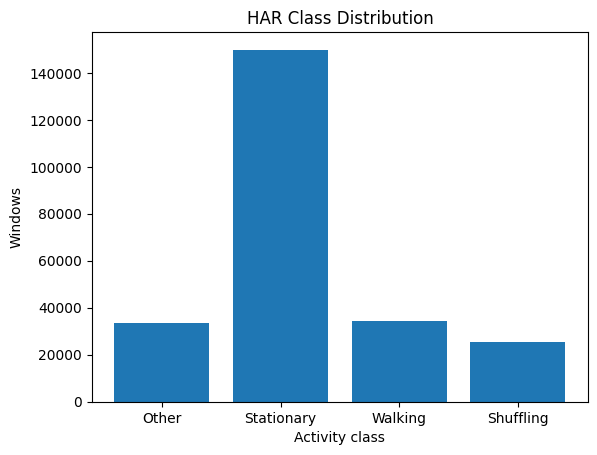

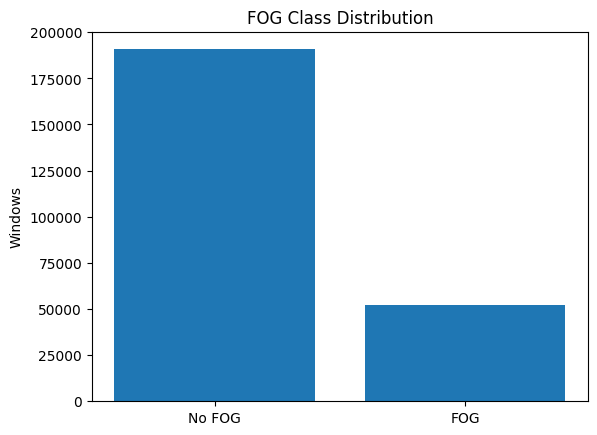

In [12]:
# Activity distribution
unique, counts = np.unique(y_activity, return_counts=True)
plt.figure()
plt.bar([FINAL_ACTIVITY_NAMES[u] for u in unique], counts)
plt.xlabel("Activity class")
plt.ylabel("Windows")
plt.title("HAR Class Distribution")
plt.show()

# FOG distribution
fu, fc = np.unique(y_fog, return_counts=True)
plt.figure()
plt.bar(["No FOG", "FOG"][:len(fu)], fc)
plt.ylabel("Windows")
plt.title("FOG Class Distribution")
plt.show()

In [13]:
# ── FIX: Subject-based three-way split (60 / 20 / 20) ─────────────────────
# Using GroupShuffleSplit ensures no subject appears in more than one split.
# This prevents the model from memorising subject-specific patterns.

gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
trainval_idx, test_idx = next(gss_outer.split(X, y_fog, groups=groups))

# Second split: carve validation out of the remaining trainval pool
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)  # 0.25 * 0.80 = 0.20
train_idx, val_idx = next(
    gss_inner.split(X[trainval_idx], y_fog[trainval_idx], groups=groups[trainval_idx])
)
train_idx = trainval_idx[train_idx]
val_idx   = trainval_idx[val_idx]

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
y_act_train = y_activity[train_idx]
y_act_val   = y_activity[val_idx]
y_act_test  = y_activity[test_idx]
y_fog_train = y_fog[train_idx].astype(np.float32)
y_fog_val   = y_fog[val_idx].astype(np.float32)
y_fog_test  = y_fog[test_idx].astype(np.float32)

print(f"Train samples : {len(X_train):,}  |  Subjects: {len(np.unique(groups[train_idx]))}")
print(f"Val   samples : {len(X_val):,}  |  Subjects: {len(np.unique(groups[val_idx]))}")
print(f"Test  samples : {len(X_test):,}  |  Subjects: {len(np.unique(groups[test_idx]))}")
print()
print(f"Train FOG pos : {y_fog_train.sum():.0f}  ({100*y_fog_train.mean():.1f} %)")
print(f"Val   FOG pos : {y_fog_val.sum():.0f}  ({100*y_fog_val.mean():.1f} %)")
print(f"Test  FOG pos : {y_fog_test.sum():.0f}  ({100*y_fog_test.mean():.1f} %)")

# Verify no subject overlap between splits
assert len(set(groups[train_idx]) & set(groups[val_idx]))  == 0, "Train/Val overlap!"
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0, "Train/Test overlap!"
assert len(set(groups[val_idx])   & set(groups[test_idx])) == 0, "Val/Test overlap!"
print("\n✅ No subject overlap between splits.")

Train samples : 155,273  |  Subjects: 12
Val   samples : 38,858  |  Subjects: 4
Test  samples : 48,713  |  Subjects: 4

Train FOG pos : 36170  (23.3 %)
Val   FOG pos : 1943  (5.0 %)
Test  FOG pos : 13974  (28.7 %)

✅ No subject overlap between splits.


In [14]:
# ── FIX: Z-score normalisation per channel ─────────────────────────────────
# Fit ONLY on training data; transform val and test with the same scaler.

n_train, T, C = X_train.shape

scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, C)
X_train     = scaler.fit_transform(X_train_2d).reshape(n_train, T, C).astype(np.float32)

X_val  = scaler.transform(X_val.reshape(-1, C)).reshape(len(X_val),  T, C).astype(np.float32)
X_test = scaler.transform(X_test.reshape(-1, C)).reshape(len(X_test), T, C).astype(np.float32)

print("Train mean (should be ~0):", X_train.reshape(-1, C).mean(axis=0).round(4))
print("Train std  (should be ~1):", X_train.reshape(-1, C).std(axis=0).round(4))

Train mean (should be ~0): [-0.  0. -0. -0. -0. -0.]
Train std  (should be ~1): [0.9927 0.9942 0.9909 0.9905 0.9905 0.9937]


In [15]:
# Activity → one-hot
y_act_oh_train = tf.keras.utils.to_categorical(y_act_train, num_activities)
y_act_oh_val   = tf.keras.utils.to_categorical(y_act_val,   num_activities)
y_act_oh_test  = tf.keras.utils.to_categorical(y_act_test,  num_activities)

print("Activity one-hot shape (train):", y_act_oh_train.shape)
print("FOG binary shape       (train):", y_fog_train.shape)

Activity one-hot shape (train): (155273, 4)
FOG binary shape       (train): (155273,)


In [16]:
def compute_activity_alpha(y_activity_labels, num_classes, minority_boost=1.4):
    """
    Compute per-class focal-loss alpha for the activity head.
    minority_boost: multiplicative factor applied to classes whose raw
    balanced weight is above the mean — pushes the model to spend more
    gradient on hard / rare activity classes.
    """
    y = np.asarray(y_activity_labels).astype(int)
    present = np.unique(y)
    bw = compute_class_weight("balanced", classes=present, y=y)
    alpha = np.zeros(num_classes, dtype=np.float32)
    alpha[present] = bw.astype(np.float32)

    # Boost minority classes (those above the mean weight)
    mean_w = alpha[present].mean()
    for cls, w in zip(present, bw):
        if w > mean_w:
            alpha[cls] *= minority_boost

    if alpha.sum() > 0:
        alpha /= alpha.sum()
    return alpha


def compute_activity_sample_weights(y_activity_labels):
    """Per-sample weights so every activity class contributes equally to the loss."""
    y = np.asarray(y_activity_labels).astype(int).reshape(-1)
    present = np.unique(y)
    bw = compute_class_weight("balanced", classes=present, y=y)
    cw_map = {int(c): float(w) for c, w in zip(present, bw)}
    sw = np.array([cw_map[int(l)] for l in y], dtype=np.float32)
    return cw_map, sw


def compute_binary_sample_weights(y_binary):
    y = np.asarray(y_binary).astype(int).reshape(-1)
    present = np.unique(y)
    bw = compute_class_weight("balanced", classes=present, y=y)
    cw_map = {int(c): float(w) for c, w in zip(present, bw)}
    sw = np.array([cw_map[int(l)] for l in y], dtype=np.float32)
    return cw_map, sw


# Computed on TRAIN only
alpha_activity = compute_activity_alpha(y_act_train, num_activities, minority_boost=1.4)
act_cw_map, act_sample_weights = compute_activity_sample_weights(y_act_train)
label_cw_map,  label_sample_weights = compute_binary_sample_weights(y_fog_train)

print("Activity alpha (focal loss, boosted):")
for cls, w in enumerate(alpha_activity):
    print(f"  Class {cls} ({FINAL_ACTIVITY_NAMES[cls]}): {w:.4f}")

print("\nActivity sample-weight map:")
for cls, w in act_cw_map.items():
    print(f"  Class {cls} ({FINAL_ACTIVITY_NAMES[cls]}): {w:.4f}")

print("\nFOG sample-weight map:")
for cls in [0, 1]:
    print(f"  Label {cls}: {label_cw_map.get(cls, 0.0):.4f}")


Activity alpha (focal loss, boosted):
  Class 0 (Other): 0.1859
  Class 1 (Stationary): 0.0475
  Class 2 (Walking): 0.3407
  Class 3 (Shuffling): 0.4259

Activity sample-weight map:
  Class 0 (Other): 1.5717
  Class 1 (Stationary): 0.4018
  Class 2 (Walking): 2.0574
  Class 3 (Shuffling): 2.5724

FOG sample-weight map:
  Label 0: 0.6518
  Label 1: 2.1464


In [17]:
class TemporalAttention(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.W = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, x):
        # x: (batch, time, features)
        score   = self.V(tf.nn.tanh(self.W(x)))   # (batch, time, 1)
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * x, axis=1)
        return context

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"units": self.units})
        return cfg

In [18]:
def categorical_focal_loss(gamma=2.0, alpha=None):
    """Multiclass focal loss. alpha: array of shape (num_classes,)"""
    if alpha is not None:
        alpha = tf.constant(alpha, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce      = -y_true * tf.math.log(y_pred)
        pt      = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal   = tf.pow(1.0 - pt, gamma)
        if alpha is not None:
            alpha_t  = tf.reduce_sum(y_true * alpha, axis=-1)
            focal   *= alpha_t
        return tf.reduce_mean(focal * tf.reduce_sum(ce, axis=-1))

    return loss

In [19]:
class DualMetricsCallback(tf.keras.callbacks.Callback):
    """
    Computes per-epoch:
      • Activity macro-F1  (across all activity classes)
      • FOG F-beta (β=2.0) at a fixed probability threshold

    Then writes a combined score:
      val_combined = 0.6 × act_macro_f1 + 0.4 × fog_f2

    Early-stopping and LR reduction monitor val_combined, so BOTH
    tasks must improve to keep training going.  The 60/40 split
    explicitly prioritises activity over FOG.
    """

    def __init__(self, X_val, y_act_val, y_fog_val,
                 fog_threshold=0.35, fog_beta=2.0,
                 act_weight=0.6, fog_weight=0.4):
        super().__init__()
        self.X_val        = X_val
        self.y_act_val    = y_act_val.astype(int)
        self.y_fog_val    = y_fog_val.astype(int)
        self.fog_threshold = fog_threshold
        self.fog_beta2    = fog_beta ** 2
        self.act_w        = act_weight
        self.fog_w        = fog_weight

    def on_epoch_end(self, epoch, logs=None):
        act_probs, fog_probs = self.model.predict(self.X_val, verbose=0)

        # ── Activity macro-F1 ─────────────────────────────────────────
        act_preds = act_probs.argmax(axis=1)
        classes   = np.unique(self.y_act_val)
        f1s = []
        for c in classes:
            tp = np.sum((act_preds == c) & (self.y_act_val == c))
            fp = np.sum((act_preds == c) & (self.y_act_val != c))
            fn = np.sum((act_preds != c) & (self.y_act_val == c))
            p  = tp / (tp + fp + 1e-8)
            r  = tp / (tp + fn + 1e-8)
            f1s.append(2 * p * r / (p + r + 1e-8))
        act_macro_f1 = float(np.mean(f1s))

        # ── FOG F-beta ────────────────────────────────────────────────
        fog_preds = (fog_probs.ravel() > self.fog_threshold).astype(int)
        tp  = np.sum((fog_preds == 1) & (self.y_fog_val == 1))
        fp  = np.sum((fog_preds == 1) & (self.y_fog_val == 0))
        fn  = np.sum((fog_preds == 0) & (self.y_fog_val == 1))
        fog_p = tp / (tp + fp + 1e-8)
        fog_r = tp / (tp + fn + 1e-8)
        fog_fbeta = ((1 + self.fog_beta2) * fog_p * fog_r /
                     (self.fog_beta2 * fog_p + fog_r + 1e-8))

        # ── Combined score (activity-priority) ───────────────────────
        combined = self.act_w * act_macro_f1 + self.fog_w * fog_fbeta

        logs["val_act_macro_f1"] = float(act_macro_f1)
        logs["val_fog_f2"]       = float(fog_fbeta)
        logs["val_combined"]     = float(combined)

        print(f"  — act_macro_f1={act_macro_f1:.4f}  "
              f"fog_f2={fog_fbeta:.4f}  (P={fog_p:.4f}, R={fog_r:.4f})  "
              f"combined={combined:.4f}")


In [20]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  ACTIVITY-PRIORITY DUAL-TASK ARCHITECTURE
#
#  Key changes vs. previous version:
#  1. Task-specific attention — activity and FOG each have their own
#     TemporalAttention(128), so each head learns which timesteps matter
#     for its task instead of sharing a single compromise context vector.
#  2. Deeper activity tower — Dense(128)→Dropout(0.4)→Dense(64)→
#     Dropout(0.3)→output; matches FOG tower depth so activity has equal
#     representational capacity.
#  3. Rebalanced loss weights — activity=2.5 / FOG=2.5; equal gradient
#     budget ends the systematic starvation of the activity head.
#  4. Higher focal gamma for activity — γ=3.0 vs 2.0 before; harder focus
#     on the windows that are still being mis-classified.
#  5. FOG pos_weight kept at neg/pos × 1.8 (no change — already well tuned).
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


def binary_focal_loss(gamma=2.0, pos_weight=None):
    def loss(y_true, y_pred):
        y_pred   = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true_f = tf.cast(y_true, tf.float32)
        bce      = -(y_true_f * tf.math.log(y_pred)
                     + (1.0 - y_true_f) * tf.math.log(1.0 - y_pred))
        p_t      = y_true_f * y_pred + (1.0 - y_true_f) * (1.0 - y_pred)
        focal_w  = tf.pow(1.0 - p_t, gamma)
        focal    = focal_w * bce
        if pos_weight is not None:
            alpha_t = y_true_f * pos_weight + (1.0 - y_true_f) * 1.0
            focal   = alpha_t * focal
        return tf.reduce_mean(focal)
    return loss


def residual_block(x, filters, kernel_size=3):
    shortcut = x
    x = layers.Conv1D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv1D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x


def multiscale_block(x, filters_per_branch=64):
    branches = []
    for k in [3, 7, 13]:
        b = layers.Conv1D(filters_per_branch, k,
                          padding="same", use_bias=False)(x)
        b = layers.BatchNormalization()(b)
        b = layers.Activation("relu")(b)
        branches.append(b)
    return layers.Concatenate()(branches)


def build_model(num_activities, alpha_activity):
    inputs = layers.Input(shape=(WINDOW_LEN, CHANNELS), name="input_layer")

    # ── Shared feature extraction ─────────────────────────────────────────
    x = multiscale_block(inputs, filters_per_branch=48)   # → 144 filters
    x = layers.MaxPooling1D(2)(x)                          # → 60 timesteps

    x = residual_block(x, filters=128, kernel_size=3)
    x = residual_block(x, filters=128, kernel_size=3)
    x = layers.MaxPooling1D(2)(x)                          # → 30 timesteps

    x = layers.Bidirectional(
        layers.GRU(64, return_sequences=True, dropout=0.3, unroll=True),
        name="bigru_1"
    )(x)
    x = layers.Bidirectional(
        layers.GRU(64, return_sequences=True, dropout=0.3, unroll=True),
        name="bigru_2"
    )(x)
    # x shape: (batch, 30, 128)

    # ── Task-specific attention heads ─────────────────────────────────────
    # Each head attends to the timesteps most relevant for its own task.
    act_context = TemporalAttention(128, name="act_attention")(x)   # (batch, 128)
    fog_context = TemporalAttention(128, name="fog_attention")(x)   # (batch, 128)

    # ── Activity tower (deeper — matches FOG tower depth) ─────────────────
    act = layers.Dense(128, activation="relu")(act_context)
    act = layers.Dropout(0.4)(act)
    act = layers.Dense(64,  activation="relu")(act)
    act = layers.Dropout(0.3)(act)
    activity_out = layers.Dense(
        num_activities, activation="softmax",
        dtype="float32", name="activity"  # float32 required for mixed precision
    )(act)

    # ── FOG tower (unchanged) ─────────────────────────────────────────────
    fog = layers.Dense(128, activation="relu")(fog_context)
    fog = layers.Dropout(0.4)(fog)
    fog = layers.Dense(64,  activation="relu")(fog)
    fog = layers.Dropout(0.3)(fog)
    fog_out = layers.Dense(1, activation="sigmoid",
                        dtype="float32", name="label")(fog)  # float32 required for mixed precision

    model = models.Model(inputs, outputs=[activity_out, fog_out])

    # ── Losses ────────────────────────────────────────────────────────────
    fog_pos = float(np.sum(y_fog_train))
    fog_neg = float(len(y_fog_train) - fog_pos)
    fog_pw  = (fog_neg / (fog_pos + 1e-8)) * 1.8
    print(f"FOG pos_weight (neg/pos × 1.8): {fog_pw:.2f}")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss={
            # γ=3.0 for activity: harder focus on persistently mis-classified windows
            "activity": categorical_focal_loss(gamma=3.0, alpha=alpha_activity),
            "label":    binary_focal_loss(gamma=2.0, pos_weight=fog_pw),
        },
        # Equal loss weights — neither task starves the other
        loss_weights={"activity": 2.5, "label": 2.5},
        metrics={
            "activity": [
                tf.keras.metrics.CategoricalAccuracy(name="acc"),
            ],
            "label": [
                tf.keras.metrics.Recall(name="recall"),
                tf.keras.metrics.Precision(name="precision"),
                tf.keras.metrics.AUC(name="auc"),
            ]
        }
    )
    return model


In [21]:
model = build_model(num_activities, alpha_activity)
model.summary()

# ── Sample weights: BOTH tasks now use class-balanced per-sample weights ──
# Previously, activity used np.ones (uniform) — minority activity classes
# received far fewer gradient updates.  Now they match FOG treatment.
train_sample_weights = [
    act_sample_weights,    # activity: class-balanced
    label_sample_weights   # FOG:      class-balanced (unchanged)
]

# ── Callbacks ─────────────────────────────────────────────────────────────
dual_cb = DualMetricsCallback(
    X_val, y_act_val, y_fog_val,
    fog_threshold=0.35,
    fog_beta=2.0,
    act_weight=0.6,    # activity contributes 60% of combined score
    fog_weight=0.4     # FOG contributes 40%
)

callbacks = [
    dual_cb,
    tf.keras.callbacks.EarlyStopping(
        monitor="val_combined",   # stops when BOTH tasks stop improving
        mode="max",
        patience=8,               # +2 extra patience vs before (balanced objective needs more time)
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_combined",
        mode="max",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train,
    [y_act_oh_train, y_fog_train],
    validation_data=(X_val, [y_act_oh_val, y_fog_val]),
    epochs=60,                    # +10 epochs vs before — more room to converge
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    sample_weight=train_sample_weights,
    verbose=1
)


FOG pos_weight (neg/pos × 1.8): 5.93


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 120, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 120, 48)   │        864 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 120, 48)   │      2,016 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 120, 48)   │      3,744 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 120, 48)   │        192 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 48)   │        192 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 48)   │        192 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 120, 48)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 120, 48)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 120, 48)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 120, 144)  │          0 │ activation[0][0], │
│ (Concatenate)       │                   │            │ activation_1[0][… │
│                     │                   │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 60, 144)   │          0 │ concatenate[0][0] │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 60, 128)   │     55,296 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 128)   │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 60, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 60, 128)   │     49,152 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 60, 128)   │     18,432 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 128)   │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 463,079 (1.77 MB)

 Trainable params: 461,511 (1.76 MB)

 Non-trainable params: 1,568 (6.12 KB)

Epoch 1/60
2427/2427 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - activity_acc: 0.5618 - activity_loss: 0.0508 - label_auc: 0.8370 - label_loss: 0.2620 - label_precision: 0.4360 - label_recall: 0.8543 - loss: 0.7819  — act_macro_f1=0.5528  fog_f2=0.2663  (P=0.0682, R=0.9717)  combined=0.4382
2427/2427 ━━━━━━━━━━━━━━━━━━━━ 333s 98ms/step - activity_acc: 0.6565 - activity_loss: 0.0405 - label_auc: 0.8879 - label_loss: 0.2273 - label_precision: 0.5008 - label_recall: 0.8759 - loss: 0.6695 - val_activity_acc: 0.8075 - val_activity_loss: 0.0243 - val_label_auc: 0.9256 - val_label_loss: 0.1377 - val_label_precision: 0.1973 - val_label_recall: 0.8935 - val_loss: 0.4054 - val_act_macro_f1: 0.5528 - val_fog_f2: 0.2663 - val_combined: 0.4382 - learning_rate: 1.0000e-04
Epoch 2/60
2427/2427 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - activity_acc: 0.7428 - activity_loss: 0.0313 - label_auc: 0.9272 - label_loss: 0.1860 - label_precision: 0.6021 - label_recall: 0.8948 - loss: 0.5432  — act_macro_f1=0.5673  fog_f2=0

608/608 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
F1.5-optimal threshold : 0.5030
  → Precision : 0.3986
  → Recall    : 0.7890
  → F1.5      : 0.6598

  Relaxing to recall-floor only (precision may be lower).
  Recall-floor threshold : 0.3143
  → Precision : 0.2308
  → Recall    : 0.9002


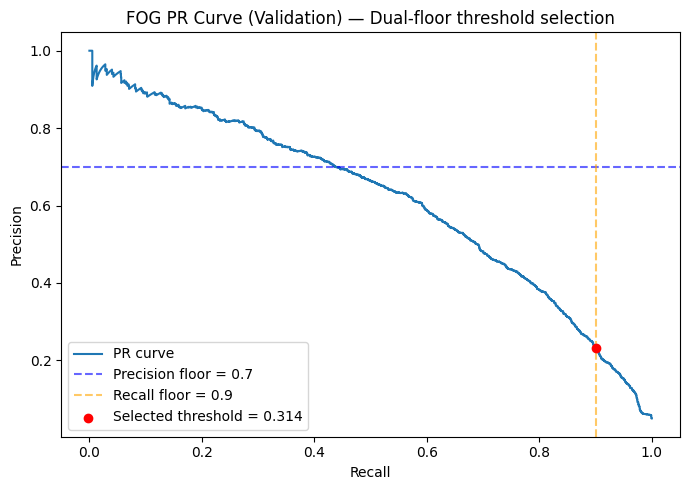

In [35]:
# ── Tune FOG threshold on VALIDATION set: dual-floor (recall + precision) ─
# Primary: F1.5-optimal threshold (β=1.5, recall weighted ~2.25× precision).
# Fallback A: if precision < PRECISION_FLOOR, search for best F1.5 among
#             thresholds satisfying BOTH floors simultaneously.
# Fallback B: if recall < RECALL_FLOOR, lower threshold until floor is met.

RECALL_FLOOR    = 0.90
PRECISION_FLOOR = 0.70   # ← lowered: don't sacrifice recall to meet precision floor

_, fog_val_probs = model.predict(X_val, batch_size=BATCH_SIZE)
fog_val_probs = fog_val_probs.ravel()

precision_vals, recall_vals, thresholds = precision_recall_curve(
    y_fog_val.astype(int), fog_val_probs
)

# ── Primary: F1.5-optimal threshold ───────────────────────────────────────
beta2   = 2.0 ** 2   # 4.0 — recall weighted 4× over precision
f15_vals = (1 + beta2) * precision_vals[:-1] * recall_vals[:-1] / (
    beta2 * precision_vals[:-1] + recall_vals[:-1] + 1e-8
)
best_idx      = np.argmax(f15_vals)
FOG_THRESHOLD = float(thresholds[best_idx])
best_recall   = float(recall_vals[best_idx])
best_prec     = float(precision_vals[best_idx])

print(f"F1.5-optimal threshold : {FOG_THRESHOLD:.4f}")
print(f"  → Precision : {best_prec:.4f}")
print(f"  → Recall    : {best_recall:.4f}")
print(f"  → F1.5      : {f15_vals[best_idx]:.4f}")

# ── Fallback A: dual-floor (precision AND recall both satisfied) ───────────
if best_prec < PRECISION_FLOOR:
    mask = (precision_vals[:-1] >= PRECISION_FLOOR) & (recall_vals[:-1] >= RECALL_FLOOR)
    if mask.any():
        valid_f15     = np.where(mask, f15_vals, 0)
        fallback_idx  = np.argmax(valid_f15)
        FOG_THRESHOLD = float(thresholds[fallback_idx])
        best_recall   = float(recall_vals[fallback_idx])
        best_prec     = float(precision_vals[fallback_idx])
        print(f"\nDual-floor fallback triggered (P>={PRECISION_FLOOR}, R>={RECALL_FLOOR})")
        print(f"  Adjusted threshold : {FOG_THRESHOLD:.4f}")
        print(f"  → Precision : {best_prec:.4f}")
        print(f"  → Recall    : {best_recall:.4f}")
    else:
        print(f"\nWarning: no threshold satisfies both floors simultaneously.")
        print(f"  Relaxing to recall-floor only (precision may be lower).")
        # Fallback B: recall floor only
        mask_r = recall_vals[:-1] >= RECALL_FLOOR
        if mask_r.any():
            fallback_idx  = np.where(mask_r)[0][-1]
            FOG_THRESHOLD = float(thresholds[fallback_idx])
            best_recall   = float(recall_vals[fallback_idx])
            best_prec     = float(precision_vals[fallback_idx])
            print(f"  Recall-floor threshold : {FOG_THRESHOLD:.4f}")
            print(f"  → Precision : {best_prec:.4f}")
            print(f"  → Recall    : {best_recall:.4f}")

# ── Plot ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, label="PR curve")
plt.axhline(PRECISION_FLOOR, color="blue",   linestyle="--",
            alpha=0.6, label=f"Precision floor = {PRECISION_FLOOR}")
plt.axvline(RECALL_FLOOR,    color="orange", linestyle="--",
            alpha=0.6, label=f"Recall floor = {RECALL_FLOOR}")
plt.scatter(best_recall, best_prec, color="red", zorder=5,
            label=f"Selected threshold = {FOG_THRESHOLD:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("FOG PR Curve (Validation) — Dual-floor threshold selection")
plt.legend()
plt.tight_layout()
plt.show()


In [36]:
# ── Final evaluation on the HELD-OUT TEST set ──────────────────────────────
y_act_pred, y_fog_pred = model.predict(X_test, batch_size=BATCH_SIZE)

y_act_pred_cls = y_act_pred.argmax(axis=1)
y_act_true_cls = y_act_oh_test.argmax(axis=1)

y_fog_pred_bin = (y_fog_pred.ravel() > FOG_THRESHOLD).astype(int)
y_fog_true_bin = y_fog_test.astype(int)

print(f"FOG threshold used : {FOG_THRESHOLD:.4f}  (tuned on val)")
print(f"Predicted FOG pos  : {y_fog_pred_bin.sum():,} / {len(y_fog_pred_bin):,}")

762/762 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
FOG threshold used : 0.3143  (tuned on val)
Predicted FOG pos  : 17,935 / 48,713


In [37]:
print("\n===== Activity (HAR) Classification Report =====")
print(classification_report(
    y_act_true_cls,
    y_act_pred_cls,
    target_names=[FINAL_ACTIVITY_NAMES[i] for i in range(num_activities)],
    digits=4
))


===== Activity (HAR) Classification Report =====
              precision    recall  f1-score   support

       Other     0.4574    0.1721    0.2501      6332
  Stationary     0.8054    0.9366    0.8661     25338
     Walking     0.7480    0.9419    0.8339      7934
   Shuffling     0.6497    0.4904    0.5589      9109

    accuracy                         0.7546     48713
   macro avg     0.6651    0.6353    0.6272     48713
weighted avg     0.7217    0.7546    0.7233     48713



In [38]:
print("\n===== FOG Detection Classification Report =====")
print(classification_report(
    y_fog_true_bin,
    y_fog_pred_bin,
    target_names=["No FOG", "FOG"],
    digits=4
))


===== FOG Detection Classification Report =====
              precision    recall  f1-score   support

      No FOG     0.9186    0.8139    0.8631     34739
         FOG     0.6395    0.8207    0.7189     13974

    accuracy                         0.8158     48713
   macro avg     0.7790    0.8173    0.7910     48713
weighted avg     0.8385    0.8158    0.8217     48713



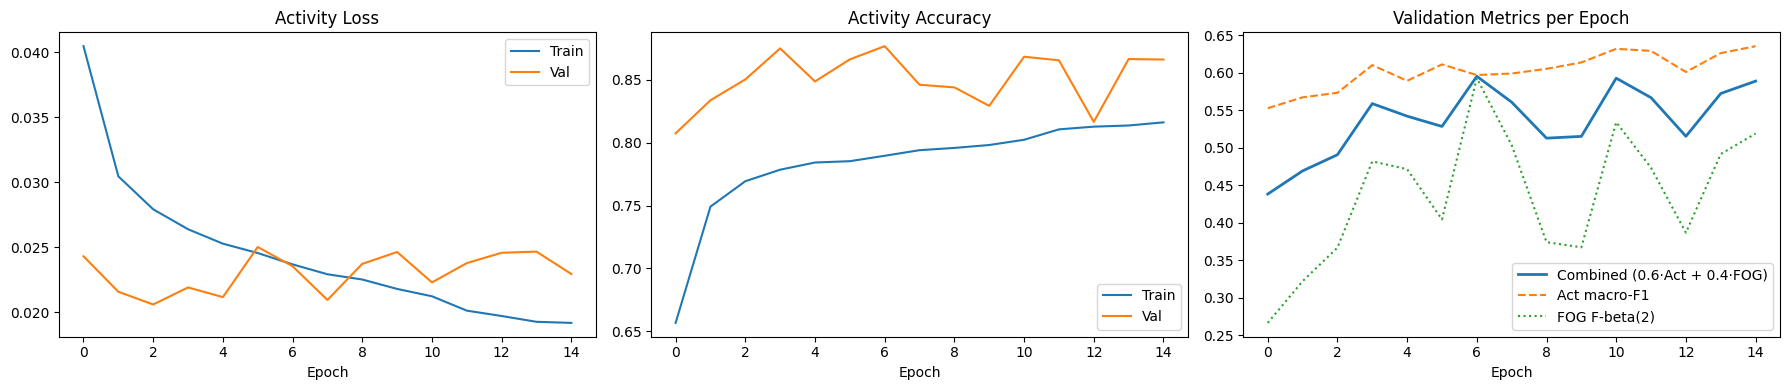

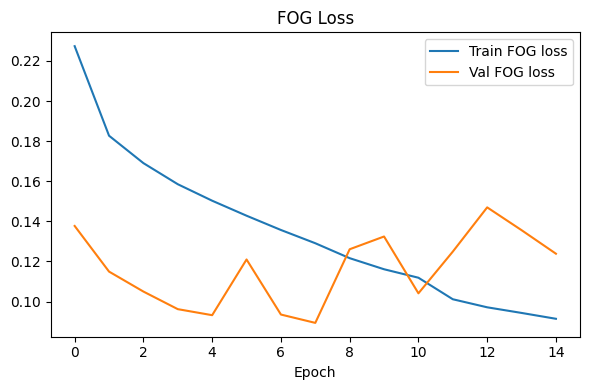

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Activity loss
axes[0].plot(history.history["activity_loss"],     label="Train")
axes[0].plot(history.history["val_activity_loss"],  label="Val")
axes[0].set_title("Activity Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# Activity accuracy
axes[1].plot(history.history["activity_acc"],     label="Train")
axes[1].plot(history.history["val_activity_acc"],  label="Val")
axes[1].set_title("Activity Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

# Combined score + per-task metrics on val
axes[2].plot(history.history["val_combined"],      label="Combined (0.6·Act + 0.4·FOG)", linewidth=2)
axes[2].plot(history.history["val_act_macro_f1"], label="Act macro-F1",  linestyle="--")
axes[2].plot(history.history["val_fog_f2"],        label="FOG F-beta(2)", linestyle=":")
axes[2].set_title("Validation Metrics per Epoch")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

# FOG loss
plt.figure(figsize=(6, 4))
plt.plot(history.history["label_loss"],    label="Train FOG loss")
plt.plot(history.history["val_label_loss"], label="Val FOG loss")
plt.title("FOG Loss")
plt.xlabel("Epoch")
plt.legend()
plt.tight_layout()
plt.show()


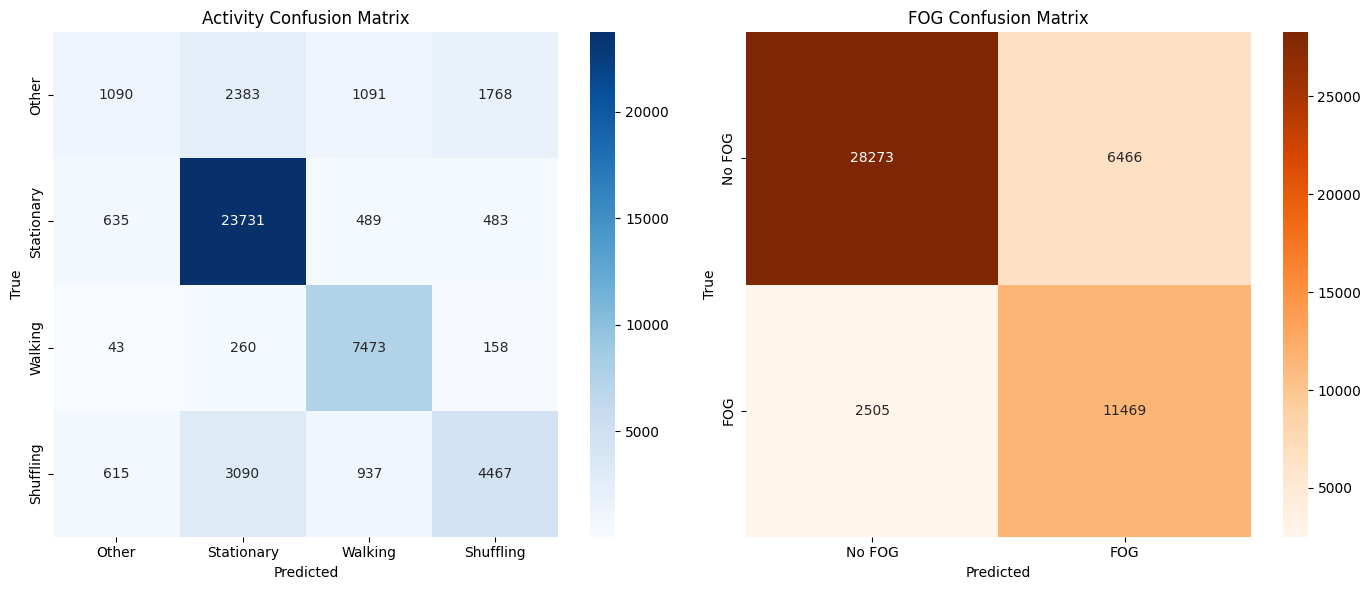

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Activity confusion matrix
cm_act = confusion_matrix(y_act_true_cls, y_act_pred_cls)
sns.heatmap(
    cm_act, annot=True, fmt="d", cmap="Blues", ax=axes[0],
    xticklabels=[FINAL_ACTIVITY_NAMES[i] for i in range(num_activities)],
    yticklabels=[FINAL_ACTIVITY_NAMES[i] for i in range(num_activities)]
)
axes[0].set_title("Activity Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# FOG confusion matrix
cm_fog = confusion_matrix(y_fog_true_bin, y_fog_pred_bin)
sns.heatmap(
    cm_fog, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
    xticklabels=["No FOG", "FOG"], yticklabels=["No FOG", "FOG"]
)
axes[1].set_title("FOG Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

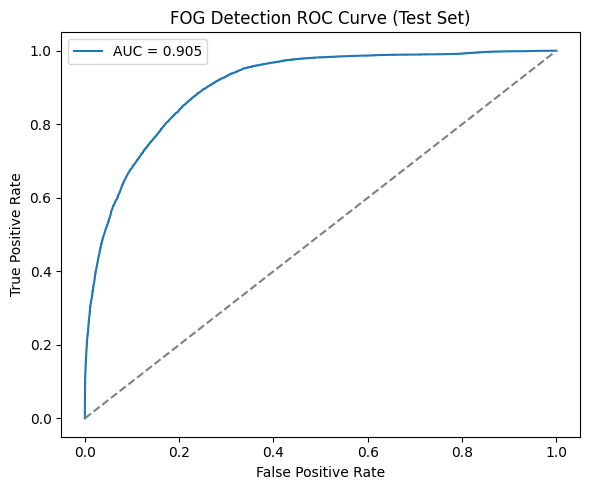

In [41]:
fpr, tpr, _ = roc_curve(y_fog_true_bin, y_fog_pred.ravel())
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("FOG Detection ROC Curve (Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
model_path = "fog_activity.keras"
model.save(model_path)
print(f"\u2705 Model saved \u2192 {model_path}")

✅ Model saved → fog_activity.keras


In [46]:
keras_model_path = "fog_activity.keras"

# 1. Load the model
# We use compile=False because we only need the graph for conversion
loaded_model = tf.keras.models.load_model(
    keras_model_path,
    custom_objects={"TemporalAttention": TemporalAttention},
    compile=False
)

# 2. Configure Converter
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)

# Enable Select TF Ops (required for GRU and certain Conv1D patterns)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

# Optimize for size/latency while keeping float32 precision for stability
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16] # Use float16 weights for 2x size reduction

# Necessary for models with GRUs/LSTMs
converter._experimental_lower_tensor_list_ops = True

try:
    tflite_model = converter.convert()
    tflite_model_path = "fog_activity.tflite"

    with open(tflite_model_path, "wb") as f:
        f.write(tflite_model)

    print(f"✅ TFLite model (Float16/Flex) saved to: {tflite_model_path}")
    print(f"Model size: {os.path.getsize(tflite_model_path) / 1024 / 1024:.2f} MB")
except Exception as e:
    print(f"❌ Conversion failed: {str(e)}")
    print("\nAttempting fallback to standard Float32...")
    converter.optimizations = []
    tflite_model = converter.convert()
    tflite_model_path = "fog_activity_standard.tflite"
    with open(tflite_model_path, "wb") as f:
        f.write(tflite_model)
    print(f"✅ Standard Float32 TFLite saved to: {tflite_model_path}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'act_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'fog_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Saved artifact at '/tmp/tmpkjv6ykab'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 120, 6), dtype=tf.float32, name='input_layer')
Output Type:
  List[TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  135396677966672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135396678116816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135396678116432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135397712557840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135397712557648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135397712558224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135397712558032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135397712558608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135397712558416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135397712558992: TensorSpe